🚀 3x3 분석 시작: 1328개 파일 처리 중...


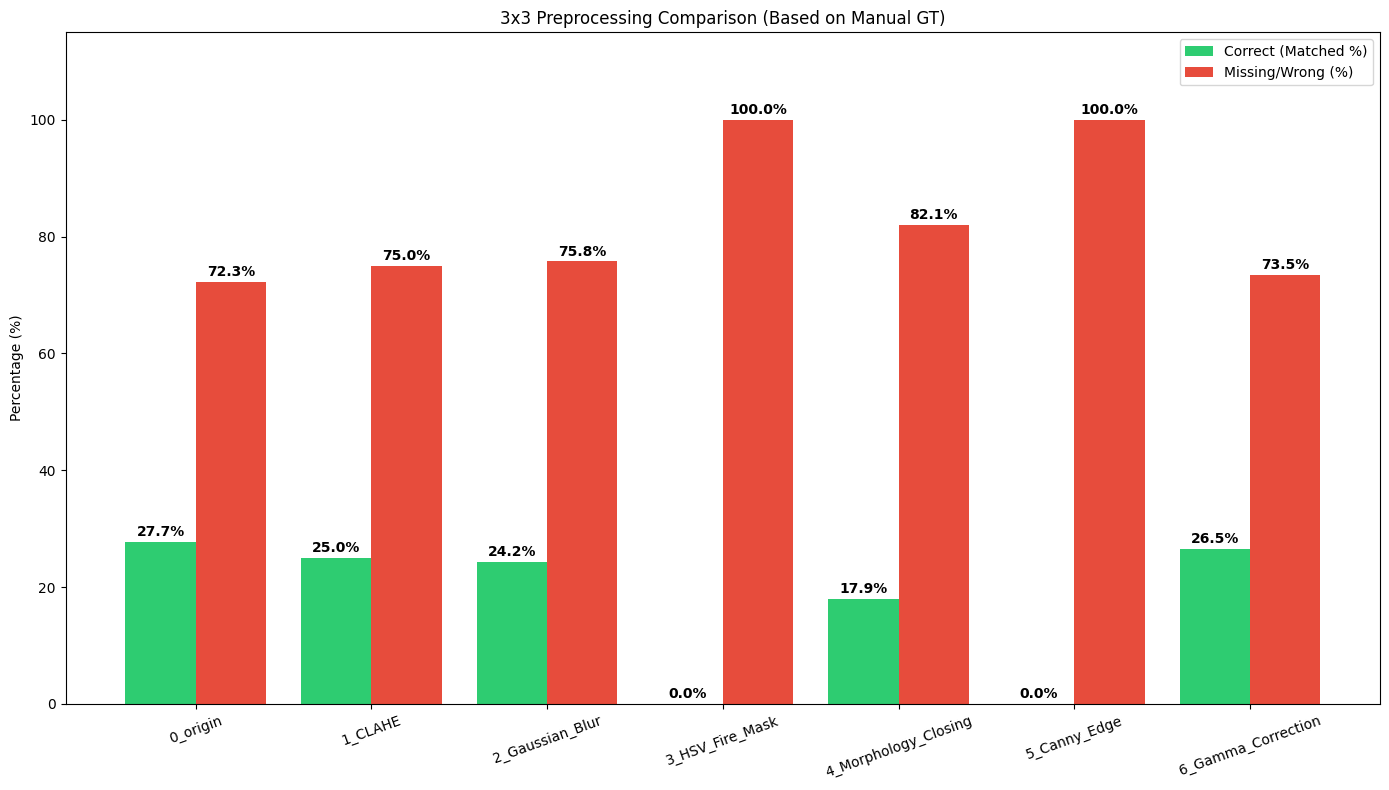

✅ 완료! 저장 위치: D:/DATA/highway_cctv/Preprocessed_Results\Final_Analysis_3x3


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tkinter import filedialog, Tk

def select_folder(title):
    root = Tk()
    root.withdraw()
    folder_selected = filedialog.askdirectory(title=title)
    root.destroy()
    return folder_selected

def calculate_iou(box1, box2):
    """Intersection over Union (IoU) 계산"""
    x1, y1, x2, y2 = max(box1[0], box2[0]), max(box1[1], box2[1]), min(box1[2], box2[2]), min(box1[3], box2[3])
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1, area2 = (box1[2]-box1[0])*(box1[3]-box1[1]), (box2[2]-box2[0])*(box2[3]-box2[1])
    union = area1 + area2 - intersection
    return intersection / union if union > 0 else 0

def get_yolo_boxes(label_path, img_w, img_h):
    """YOLO txt 파일에서 박스 좌표 복원 (정규화 -> 픽셀)"""
    boxes = []
    if not os.path.exists(label_path): return boxes
    with open(label_path, 'r', encoding='utf-8') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) < 5: continue
            cls, x, y, w, h = map(float, parts[:5])
            boxes.append([
                int((x - w/2) * img_w), int((y - h/2) * img_h),
                int((x + w/2) * img_w), int((y + h/2) * img_h)
            ])
    return boxes

def process_3x3_analysis():
    # 1. 폴더 선택
    base_path = select_folder("전처리 폴더들이 포함된 '상위 폴더'를 선택하세요")
    if not base_path: return
    
    gt_label_path = select_folder("원본(수동 정답) 라벨(.txt) 폴더를 선택하세요")
    if not gt_label_path: return

    # 결과 저장 폴더 생성
    output_dir = os.path.join(base_path, "Final_Analysis_3x3")
    os.makedirs(output_dir, exist_ok=True)

    # 2. 하위 전처리 폴더 리스트업 (최대 9개까지 수집)
    target_folders = sorted([f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f)) 
                               and f != "Final_Analysis_3x3"])[:9]
    
    if not target_folders:
        print("❌ 비교할 폴더가 없습니다.")
        return

    # 첫 번째 폴더 기준으로 이미지 파일 목록 가져오기
    img_list_dir = os.path.join(base_path, target_folders[0], 'images')
    image_files = [f for f in os.listdir(img_list_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # 통계 데이터: {폴더명: [TP_Count, GT_Total]}
    folder_stats = {folder: [0, 0] for folder in target_folders}

    print(f"🚀 3x3 분석 시작: {len(image_files)}개 파일 처리 중...")

    for file_name in image_files:
        grid_cells = []
        gt_file_name = os.path.splitext(file_name)[0] + ".txt"
        
        for folder in target_folders:
            img_path = os.path.join(base_path, folder, 'images', file_name)
            pred_label_path = os.path.join(base_path, folder, 'labels', gt_file_name)
            
            if not os.path.exists(img_path):
                grid_cells.append(np.zeros((400, 533, 3), np.uint8)) # 사이즈 축소 (3x3 대비)
                continue

            img = cv2.imread(img_path)
            h, w = img.shape[:2]
            
            gt_boxes = get_yolo_boxes(os.path.join(gt_label_path, gt_file_name), w, h)
            auto_boxes = get_yolo_boxes(pred_label_path, w, h)
            
            tp = 0
            for gt in gt_boxes:
                for auto in auto_boxes:
                    if calculate_iou(gt, auto) > 0.45:
                        tp += 1
                        break
            
            folder_stats[folder][0] += tp
            folder_stats[folder][1] += len(gt_boxes)

            # 시각화
            annotated_img = img.copy()
            for auto in auto_boxes: cv2.rectangle(annotated_img, (auto[0], auto[1]), (auto[2], auto[3]), (0, 0, 255), 2)
            for gt in gt_boxes: cv2.rectangle(annotated_img, (gt[0], gt[1]), (gt[2], gt[3]), (255, 0, 0), 2)

            current_acc = (tp / len(gt_boxes) * 100) if len(gt_boxes) > 0 else 100.0
            info_text = f"{folder} | {current_acc:.1f}%"
            cv2.rectangle(annotated_img, (0, 0), (w, 80), (255, 255, 255), -1)
            cv2.putText(annotated_img, info_text, (10, 55), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 0), 3)
            
            # 3x3 격자를 위해 가로 533, 세로 400으로 리사이즈 (전체 약 1600x1200)
            grid_cells.append(cv2.resize(annotated_img, (533, 400)))

        # 3. 3x3 격자 병합 (부족하면 검은 배경으로 9개 채움)
        while len(grid_cells) < 9:
            grid_cells.append(np.zeros((400, 533, 3), np.uint8))
            
        row1 = cv2.hconcat(grid_cells[0:3])
        row2 = cv2.hconcat(grid_cells[3:6])
        row3 = cv2.hconcat(grid_cells[6:9])
        final_grid = cv2.vconcat([row1, row2, row3])
        
        cv2.imwrite(os.path.join(output_dir, f"grid_3x3_{file_name}"), final_grid)

    # 4. 성능 비교 그래프 출력
    names = list(folder_stats.keys())
    success_rates = [(stats[0]/stats[1]*100 if stats[1]>0 else 0) for stats in folder_stats.values()]
    fail_rates = [100 - r for r in success_rates]

    x = np.arange(len(names))
    width = 0.4 

    fig, ax = plt.subplots(figsize=(14, 8))
    ax.bar(x - width/2, success_rates, width, label='Correct (Matched %)', color='#2ecc71')
    ax.bar(x + width/2, fail_rates, width, label='Missing/Wrong (%)', color='#e74c3c')

    ax.set_ylabel('Percentage (%)')
    ax.set_title('3x3 Preprocessing Comparison (Based on Manual GT)')
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=20)
    ax.set_ylim(0, 115)
    ax.legend()

    for i, v in enumerate(success_rates):
        ax.text(i - width/2, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
    for i, v in enumerate(fail_rates):
        ax.text(i + width/2, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "Final_Performance_Graph.png"))
    plt.show()

    print(f"✅ 완료! 저장 위치: {output_dir}")

if __name__ == "__main__":
    process_3x3_analysis()